# Overlap experiment: a sliding window for two models

**Purpose.** Standard inference cuts the tile into fixed, side-by-side squares.
This experiment slides the window with overlap, runs each model on every window,
and keeps a pixel as burned only if most windows agree (a majority vote). We test
both models so we can see the effect of overlap and compare the models at once.

**Dataset.** Burned-area maps of tile T29TPG at 0%, 25%, 50% and 75% overlap for
both Swin-YNet and EfficientNet-B2, all with the same before image (2025-07-07)
and after image (2025-10-15), scored against the official ICNF fire records.

**Objectives.** (1) Measure how overlap changes accuracy for each model; (2)
compare the two models; (3) map the result; (4) measure the cost.

**Caveat.** The EfficientNet results depend on a band order taken from the
model's config comment, not yet confirmed with the model author, so treat the
EfficientNet numbers as provisional.

## 1. Setup and data

This section loads every overlap map for both models and builds a shared,
fairly-scored ground truth. It matters because all comparisons depend on a
common reference. The reader will see which maps exist and how scoring is set.

### 1.1 Environment and plotting style

Import libraries and fix one clean style, a colour per model, and a colour per
confusion class.

In [1]:
import sys, re
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import contextily as ctx

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 140, "font.size": 11,
    "axes.titlesize": 12, "axes.titleweight": "medium",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
MODEL_COLOR = {"swin_ynet": "#4477aa", "efficientnet_b2": "#cc6677"}
MODEL_LABEL = {"swin_ynet": "Swin-YNet", "efficientnet_b2": "EfficientNet-B2"}
C_AGREE = "#762a83"; C_FALSE = "#d6604d"; C_MISS = "#2c7bb6"

for _c in (Path.cwd(), Path.cwd().parent):
    if (_c / "utils" / "config.py").exists():
        sys.path.insert(0, str(_c)); break
from utils.config import load_config
cfg = load_config()

### 1.2 Discover the overlap maps for both models

Find every `<model>_ov<pct>` map for this before/after pair and read them, plus a
common observed mask and the study-area footprint clipped to Portugal.

In [2]:
BEFORE, AFTER = "2025-07-07", "2025-10-15"
B, A = BEFORE.replace("-", ""), AFTER.replace("-", "")
PRED_DIR = cfg.predictions_dir
LABELS   = cfg.repo_root / "data/processed/icnf_burned_labels_t29tpg_2025.tif"
ICNF_SHP = cfg.repo_root / "data/shapefiles/ground_truth_ICNF/ardida_2025.shp"
PT_BOUND = cfg.repo_root / "data/shapefiles/boundary_files/portugal_continental_32629.gpkg"
PIX_HA = 0.01

def read(p):
    with rasterio.open(p) as r: return r.read(1)

def discover(kind):
    out = {}
    for p in PRED_DIR.glob(f"T29TPG_*_ov*_{B}_{A}_{kind}.tif"):
        m = re.search(rf"T29TPG_(.+?)_ov(\d+)_{B}_{A}_", p.name)
        if m: out[(m.group(1), int(m.group(2)))] = p
    return out

burned_maps = discover("burned")
MODELS   = sorted({k[0] for k in burned_maps})
OVERLAPS = sorted({k[1] for k in burned_maps})
labels = read(LABELS)
with rasterio.open(LABELS) as _r:
    GRID_T, GRID_SHAPE = _r.transform, (_r.height, _r.width)
    EXTENT = (_r.bounds.left, _r.bounds.right, _r.bounds.bottom, _r.bounds.top)
PT = gpd.read_file(PT_BOUND).to_crs("EPSG:32629")
inside_pt = rasterize([(g, 1) for g in PT.geometry], out_shape=GRID_SHAPE,
                      transform=GRID_T, fill=0, dtype="uint8").astype(bool)
scored = (labels != 255) & inside_pt
obs0 = read(discover("observed")[(MODELS[0], OVERLAPS[0])])
comp = (obs0 == 1) & scored
print("models:", MODELS, "| overlaps:", OVERLAPS)

models: ['efficientnet_b2', 'swin_ynet'] | overlaps: [0, 25, 50, 75]


### 1.3 Ground truth within the window

Keep only ICNF fires that started on or after the before image and ended on or
before the after image, shrink each by one pixel, and rasterize.

In [3]:
fires = gpd.read_file(ICNF_SHP).to_crs("EPSG:32629")
fires = fires.cx[EXTENT[0]:EXTENT[1], EXTENT[2]:EXTENT[3]].copy()
fires["s"] = pd.to_datetime(fires["DH_Inicio"]); fires["e"] = pd.to_datetime(fires["DH_Fim"])
sel = fires[(fires["s"] >= pd.Timestamp(BEFORE)) & (fires["e"] <= pd.Timestamp(AFTER))]
geoms = [g for g in sel.geometry.buffer(-10) if not g.is_empty]
truth = rasterize([(g, 1) for g in geoms], out_shape=GRID_SHAPE,
                  transform=GRID_T, fill=0, dtype="uint8").astype(bool)
t = truth & comp
print(f"ground-truth fire in window: {t.sum()*PIX_HA:,.0f} ha")

ground-truth fire in window: 10,636 ha


## 2. Overview: how the sliding windows overlap

Before the results, a look at the mechanism itself: the 256-pixel windows and how
much they overlap at each setting. It matters because the overlap amount is what
drives the whole experiment. The reader will see the windows go from side by side
to heavily stacked.

### 2.1 How much the windows overlap

We colour the whole study area by how many windows cover each spot, at each
overlap. That count is the overlap, and it equals the number of votes a pixel
gets.

#### 2.1.1 Overlap across the study area

**Objective.** Show the overlap over the whole tile by drawing the windows
transparently, so where they stack the blue deepens. **Assumption.** Each window
adds a little red; at 0% there is one window per spot (faint), up to 16 at 75%
(deep blue).

In [4]:
CS = 256
H, W = GRID_SHAPE
footprint = read(discover("observed")[(MODELS[0], OVERLAPS[0])]) != 255

def window_starts(n, step, win=CS):
    xs = list(range(0, n - win + 1, step))
    if not xs or xs[-1] != n - win:
        xs.append(n - win)
    return xs

def coverage_count(step):
    """How many 256-windows cover each pixel (separable, so cheap)."""
    rc = np.zeros(H, int); cc = np.zeros(W, int)
    for r in window_starts(H, step): rc[r:r + CS] += 1
    for c in window_starts(W, step): cc[c:c + CS] += 1
    return np.outer(rc, cc)

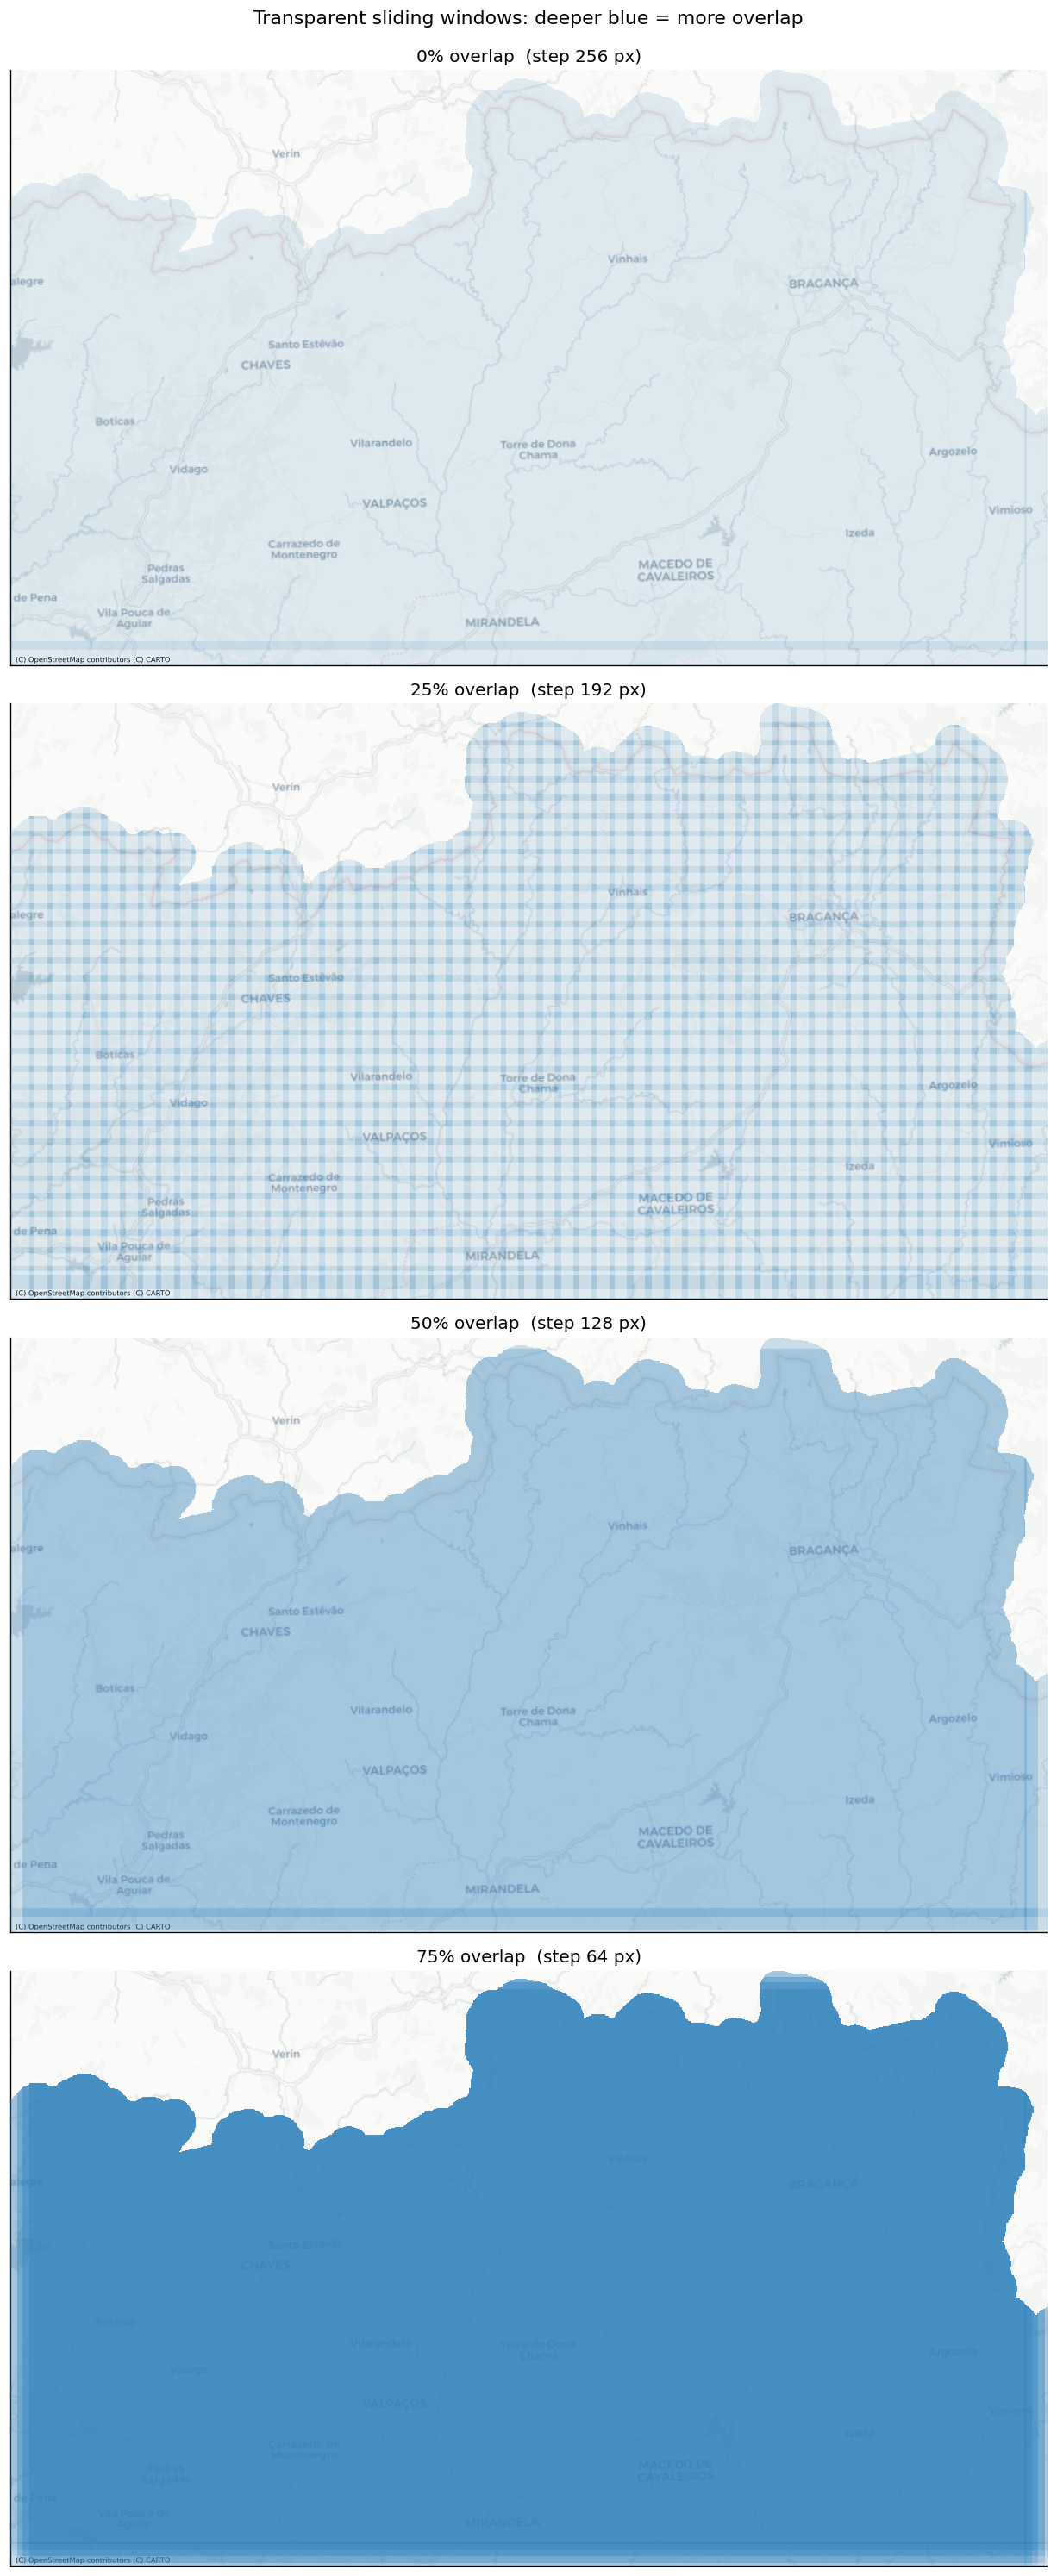

In [5]:
k = 10                       # shrink for display
footd = footprint[::k, ::k]
WIN_ALPHA = 0.13             # per-window opacity; transparent windows stack to deeper blue
BLUE = (0.19, 0.51, 0.74)    # calm blue
fig, axes = plt.subplots(4, 1, figsize=(11, 25))
for ax, ov in zip(axes, OVERLAPS):
    step = max(1, round(CS * (1 - ov/100)))
    cov = coverage_count(step)[::k, ::k]
    alpha = 1 - (1 - WIN_ALPHA) ** cov
    alpha[~footd] = 0
    rgba = np.zeros(cov.shape + (4,))
    rgba[..., 0], rgba[..., 1], rgba[..., 2] = BLUE
    rgba[..., 3] = alpha
    ax.set_xlim(EXTENT[0], EXTENT[1]); ax.set_ylim(EXTENT[2], EXTENT[3]); ax.set_aspect("equal")
    try:
        ctx.add_basemap(ax, crs="EPSG:32629", source=ctx.providers.CartoDB.Positron, attribution_size=5)
    except Exception as e:
        ax.set_facecolor("#f5f5f5"); print("basemap unavailable:", e)
    ax.imshow(rgba, extent=EXTENT, origin="upper", interpolation="nearest", zorder=3)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(f"{ov}% overlap  (step {step} px)")
fig.suptitle("Transparent sliding windows: deeper blue = more overlap", y=0.995)
plt.tight_layout(); plt.show()

**Interpretation.** At 0% overlap each spot has a single faint window, so there is
no overlap and the run matches the chunk-based pass. As overlap rises the windows
stack and the blue deepens, about 4 deep at 50% and up to 16 at 75%. That depth is
exactly the number of votes each pixel gets, which is what makes a stricter vote
possible at higher overlap.

### 2.2 How the pipeline processes the chips

The standard pipeline runs the cube's chips in batches of 8. We show that order so
it is clear which chips are processed first and how the run moves across the tile.

#### 2.2.1 Chip processing order

**Objective.** Show the order the 959 chips are processed, in groups of 8.
**Assumption.** Each batch of 8 chips is drawn as a distinct colour block (the
colour cycles every 20) and labelled with its order number (1 to 120); the cube
stores chips column by column.

In [6]:
import h5py
with h5py.File(cfg.hdf5_path, "r") as hf:
    cxb = hf["chip_x_bin"][:]; cyb = hf["chip_y_bin"][:]; cpc = hf["chip_pixel_count"][:]
CS_M = 2560.0                          # one chip = 256 px x 10 m
chip_ids = np.nonzero(cpc > 0)[0]
chip_batch = np.arange(len(chip_ids)) // 8     # batch index 0..n-1
n_batches = int(chip_batch.max()) + 1
print(f"{len(chip_ids)} chips processed in {n_batches} batches of 8")

959 chips processed in 120 batches of 8


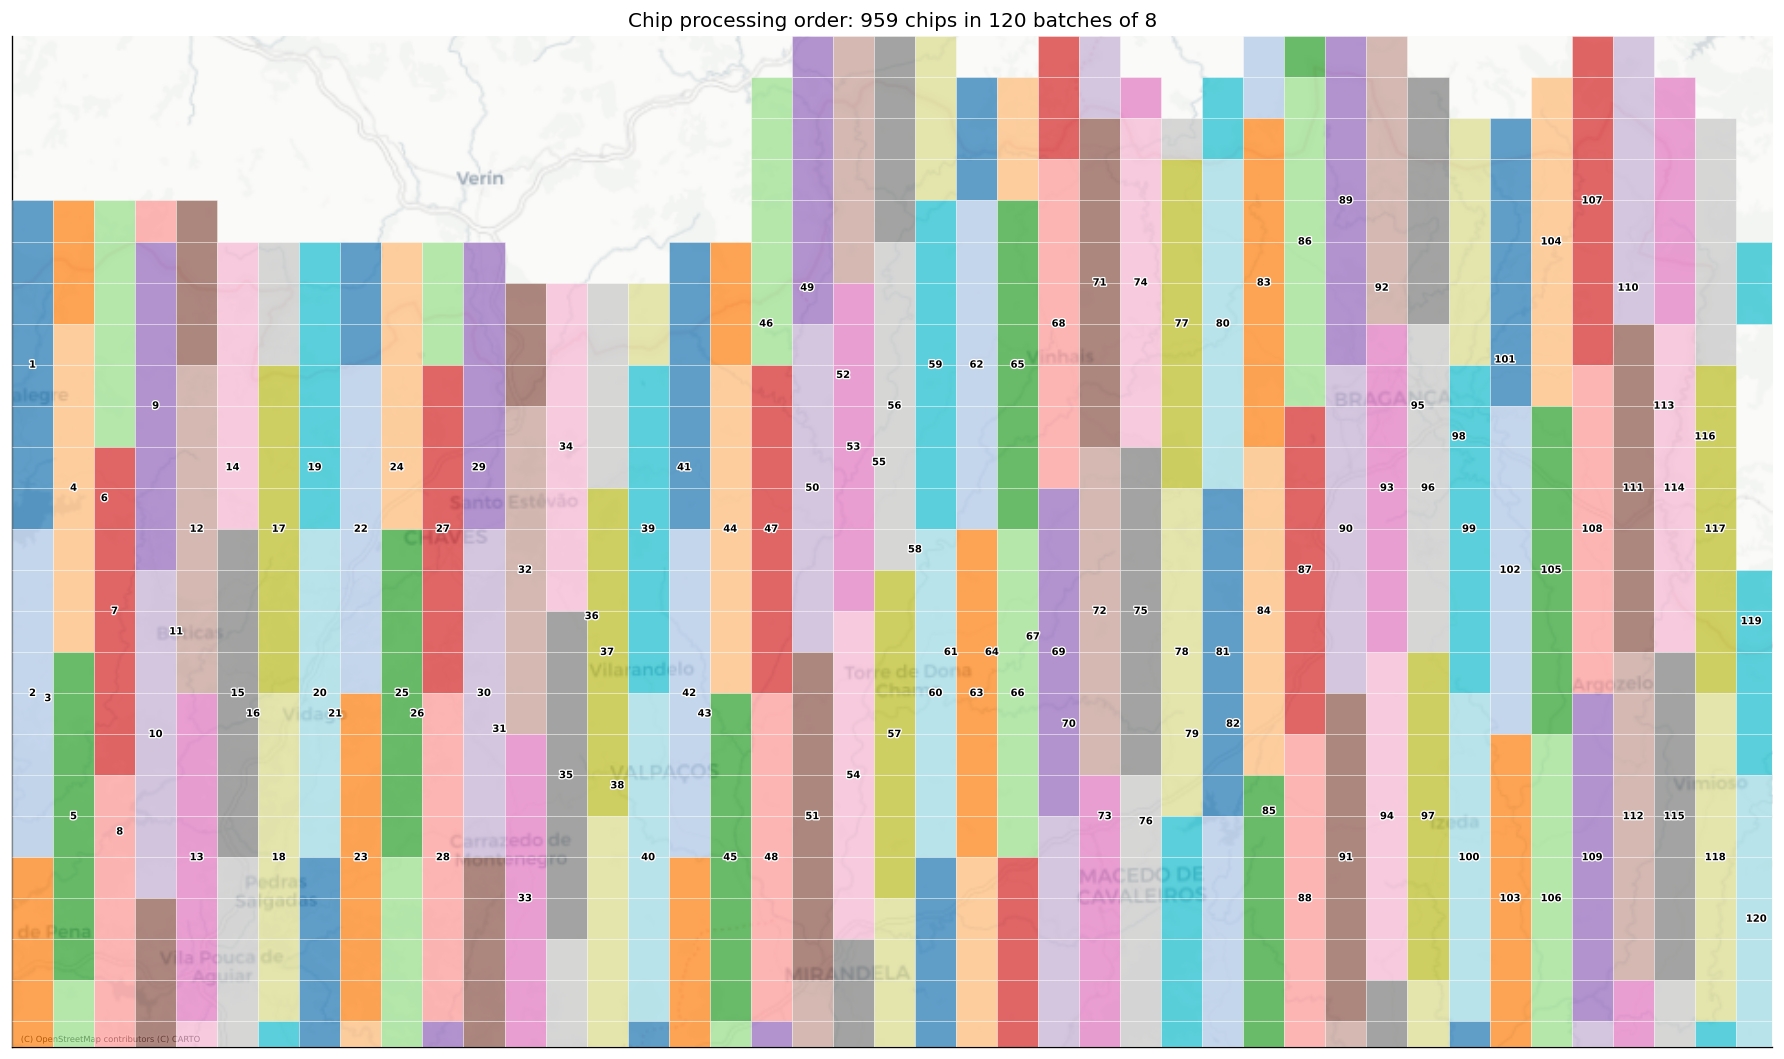

In [7]:
import matplotlib.patheffects as pe
fig, ax = plt.subplots(figsize=(15, 9))
ax.set_xlim(EXTENT[0], EXTENT[1]); ax.set_ylim(EXTENT[2], EXTENT[3]); ax.set_aspect("equal")
try:
    ctx.add_basemap(ax, crs="EPSG:32629", source=ctx.providers.CartoDB.Positron, attribution_size=5)
except Exception as e:
    ax.set_facecolor("#f5f5f5"); print("basemap unavailable:", e)
cmap = plt.get_cmap("tab20")
# colour each chip by its batch; the colour cycles every 20 so adjacent batches differ
for k, i in enumerate(chip_ids):
    x = EXTENT[0] + int(cxb[i])*CS_M; y = EXTENT[3] - (int(cyb[i]) + 1)*CS_M
    ax.add_patch(plt.Rectangle((x, y), CS_M, CS_M, facecolor=cmap(chip_batch[k] % 20),
                               edgecolor="white", lw=0.3, alpha=0.7, zorder=3))
# annotate each batch (1..n) at its centre, with a white halo for readability
for b in range(n_batches):
    sel = chip_ids[chip_batch == b]
    cx = EXTENT[0] + (cxb[sel].mean() + 0.5)*CS_M
    cy = EXTENT[3] - (cyb[sel].mean() + 0.5)*CS_M
    ax.text(cx, cy, str(b + 1), ha="center", va="center", fontsize=6, color="black",
            fontweight="bold", zorder=4,
            path_effects=[pe.withStroke(linewidth=1.6, foreground="white")])
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Chip processing order: {len(chip_ids)} chips in {n_batches} batches of 8")
plt.tight_layout(); plt.show()

**Interpretation.** Each numbered block is one batch of 8 chips. The pipeline
processes them column by column, top to bottom: batch 1 is the top of the leftmost
column, and the run marches down each column and rightward to batch 120 on the far
right. This is the cube's storage order.

## 3. Accuracy versus overlap, by model

This section measures accuracy for each model across overlap. It matters because
it answers both questions at once: does overlap help, and which model is better.

### 3.1 Confusion-based statistics

Build the confusion matrix for every model and overlap, then derive the scores.

#### 3.1.1 Burned area by model and overlap

**Objective.** Track the total area each model calls burned as overlap rises, and
compare it with the actual fire. **Assumption.** Scored on the shared footprint
inside Portugal.

In [8]:
def mcc(tp, fp, fn, tn):
    tp, fp, fn, tn = map(float, (tp, fp, fn, tn))
    d = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)); return (tp*tn-fp*fn)/d if d else 0.0

rows = []
for mdl in MODELS:
    for ov in OVERLAPS:
        p = (read(burned_maps[(mdl, ov)]) == 1) & comp
        TP = int((p & t).sum()); FP = int((p & ~t).sum())
        FN = int((~p & t).sum()); TN = int((~p & ~t & comp).sum())
        rows.append({"model": mdl, "overlap": ov, "burned_ha": (TP+FP)*PIX_HA,
                     "precision": TP/(TP+FP), "recall": TP/(TP+FN),
                     "F1": 2*TP/(2*TP+FP+FN), "MCC": mcc(TP, FP, FN, TN)})
stats = pd.DataFrame(rows)
stats.round(3)

,model,overlap,burned_ha,precision,recall,F1,MCC
0,efficientnet_b2,0,17456.40,0.554,0.909,0.688,0.702
1,efficientnet_b2,25,15586.39,0.620,0.909,0.737,0.745
2,efficientnet_b2,50,15019.56,0.646,0.912,0.756,0.762
3,efficientnet_b2,75,16039.81,0.613,0.925,0.737,0.747
4,swin_ynet,0,25003.83,0.364,0.856,0.511,0.546
5,swin_ynet,25,22914.85,0.397,0.855,0.542,0.571
6,swin_ynet,50,18734.86,0.481,0.848,0.614,0.630
7,swin_ynet,75,21371.63,0.439,0.882,0.586,0.613


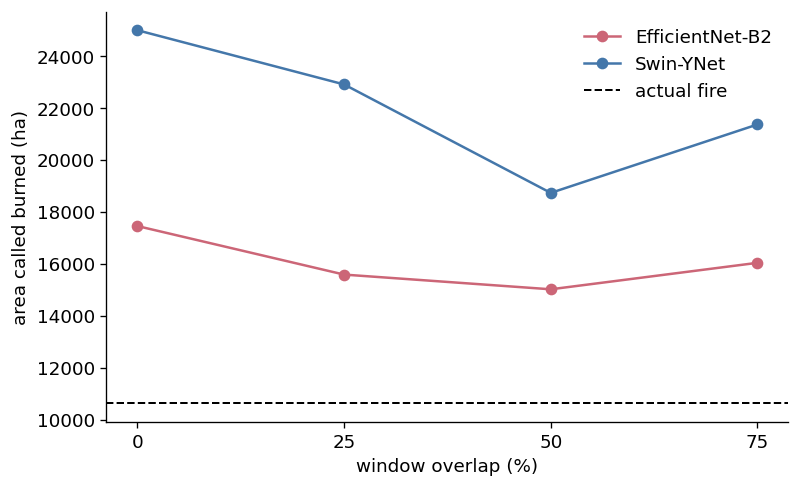

In [9]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
for mdl in MODELS:
    s = stats[stats.model == mdl]
    ax.plot(s["overlap"], s["burned_ha"], "o-", color=MODEL_COLOR[mdl], label=MODEL_LABEL[mdl])
ax.axhline(t.sum()*PIX_HA, ls="--", color="black", lw=1.2, label="actual fire")
ax.set_xlabel("window overlap (%)"); ax.set_ylabel("area called burned (ha)")
ax.set_xticks(OVERLAPS); ax.legend()
plt.tight_layout(); plt.show()

**Interpretation.** EfficientNet calls far less area burned than Swin-YNet,
landing much closer to the actual fire line. Both models dip to a minimum near
50% overlap, then rise slightly at 75%.

#### 3.1.2 Detection scores by model and overlap

**Objective.** Compare precision, recall, F1 and MCC across overlap for both
models. **Assumption.** Same confusion numbers as above.

In [10]:
stats.pivot_table(index="overlap", columns="model", values=["F1", "MCC"]).round(3)

F1                       MCC          
model   efficientnet_b2 swin_ynet efficientnet_b2 swin_ynet
overlap                                                    
0                 0.688     0.511           0.702     0.546
25                0.737     0.542           0.745     0.571
50                0.756     0.614           0.762     0.630
75                0.737     0.586           0.747     0.613

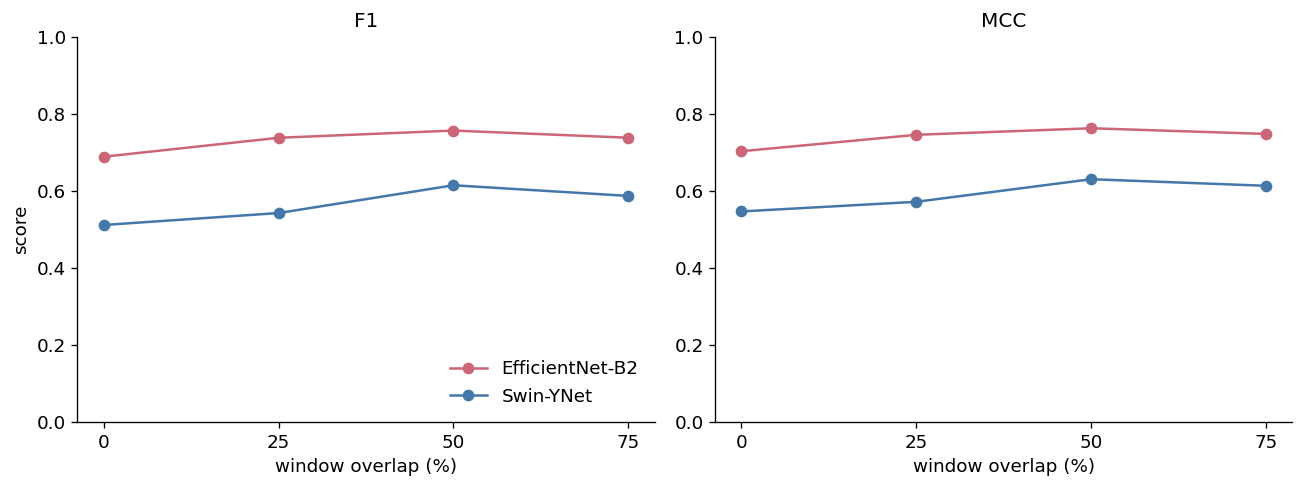

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
for ax, metric in zip(axes, ["F1", "MCC"]):
    for mdl in MODELS:
        s = stats[stats.model == mdl]
        ax.plot(s["overlap"], s[metric], "o-", color=MODEL_COLOR[mdl], label=MODEL_LABEL[mdl])
    ax.set_title(metric); ax.set_xlabel("window overlap (%)")
    ax.set_ylim(0, 1); ax.set_xticks(OVERLAPS)
axes[0].set_ylabel("score"); axes[0].legend(loc="lower right")
plt.tight_layout(); plt.show()

**Interpretation.** EfficientNet scores higher than Swin-YNet at every
overlap on both F1 and MCC. For both models the scores peak at 50% overlap and
dip at 75%, so 50% is the best setting for either model.

## 4. Spatial result

This section maps agreement and error for both models across overlap, so the
spatial differences are visible. The reader will see where each model is right
and wrong, and how overlap cleans it up.

### 4.1 Per-setting agreement maps

Violet = true positive (agreement), red = false positive (false alarm), blue = false negative (missed). Rows are models, columns are
overlap settings.

#### 4.1.1 Agreement map for each model and overlap

**Objective.** Show the spatial confusion for both models from 0% to 75%.
**Assumption.** Maps are shrunk for display, with the Portugal boundary drawn.

In [12]:
def pool_or(a, k=12):
    H, W = (a.shape[0]//k)*k, (a.shape[1]//k)*k
    return a[:H, :W].reshape(H//k, k, W//k, k).max(axis=(1, 3))
def confusion_rgb(mdl, ov):
    p = (read(burned_maps[(mdl, ov)]) == 1) & comp
    TP, FP, FN = pool_or(p & t), pool_or(p & ~t), pool_or(~p & t)
    img = np.ones(TP.shape + (3,))
    for m, c in [(FN, C_MISS), (FP, C_FALSE), (TP, C_AGREE)]:
        img[m] = mcolors.to_rgb(c)
    return img

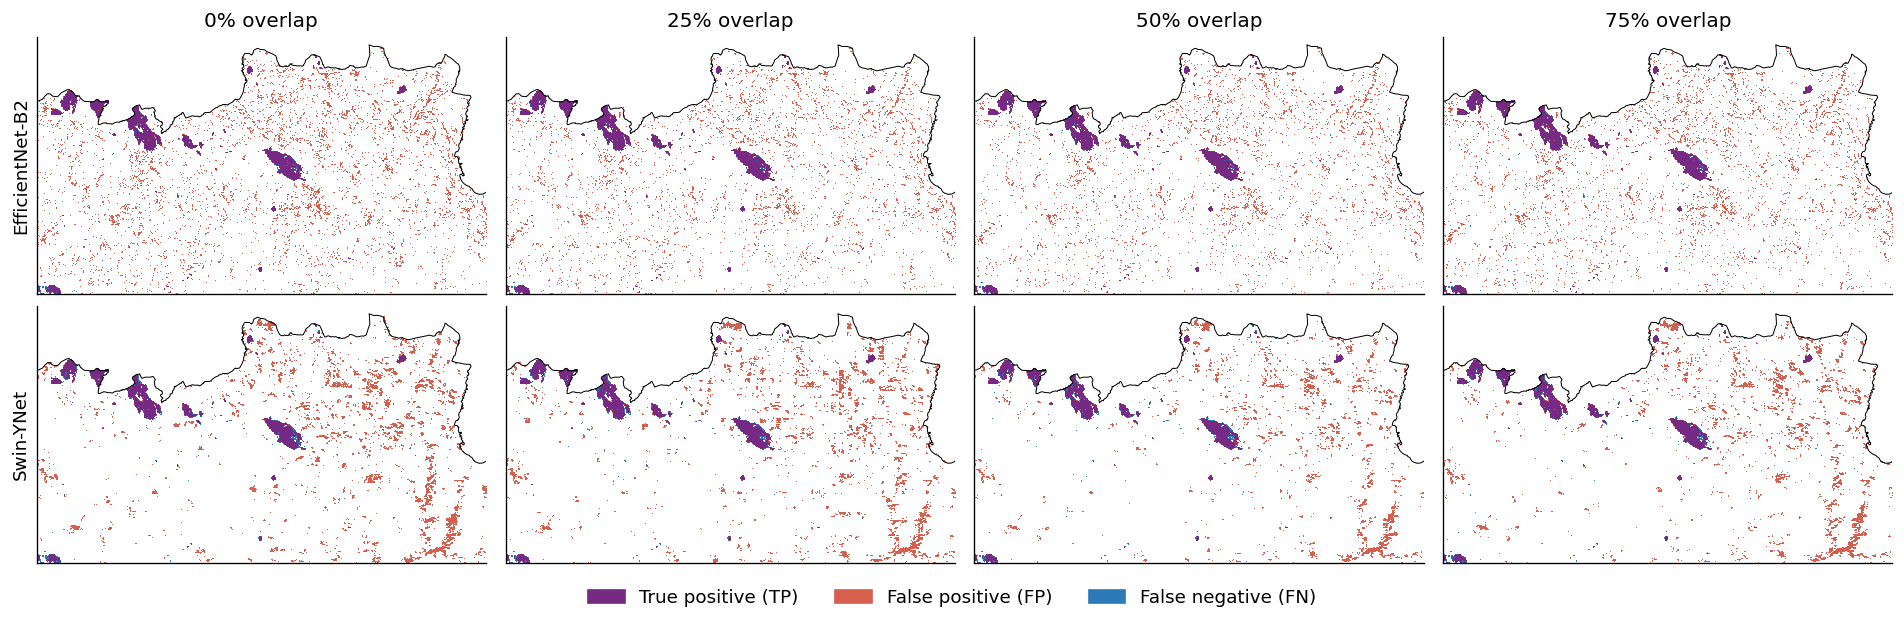

In [13]:
fig, axes = plt.subplots(len(MODELS), len(OVERLAPS), figsize=(4*len(OVERLAPS), 2.6*len(MODELS)))
axes = np.atleast_2d(axes)
for i, mdl in enumerate(MODELS):
    for j, ov in enumerate(OVERLAPS):
        ax = axes[i, j]
        ax.imshow(confusion_rgb(mdl, ov), extent=EXTENT, origin="upper", interpolation="nearest")
        PT.boundary.plot(ax=ax, color="black", linewidth=0.6)
        ax.set_xlim(EXTENT[0], EXTENT[1]); ax.set_ylim(EXTENT[2], EXTENT[3])
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0: ax.set_title(f"{ov}% overlap")
        if j == 0: ax.set_ylabel(MODEL_LABEL[mdl])
handles = [mpatches.Patch(color=C_AGREE, label="True positive (TP)"),
           mpatches.Patch(color=C_FALSE, label="False positive (FP)"),
           mpatches.Patch(color=C_MISS, label="False negative (FN)")]
fig.legend(handles=handles, loc="lower center", ncol=3)
plt.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

**Interpretation.** EfficientNet (bottom row) shows much less red than
Swin-YNet (top row) at every overlap, confirming it makes far fewer false alarms.
For both, the red thins toward 50% overlap.

## 5. Computational cost

This section reports run time and memory for each model and overlap. It matters
because overlap is only worth it if affordable. The reader will see how cost
scales.

#### 5.1.1 Time and memory by model and overlap

**Objective.** Compare run time and peak memory across overlap for both models.
**Assumption.** Measured on CPU; run time and window count from the run logs,
peak memory from the instrumented runner.

In [14]:
# measured on this machine (CPU): run time and peak memory per model and overlap
TIME_S = {"swin_ynet":      {0: 257, 25: 399, 50: 995, 75: 3310},
          "efficientnet_b2": {0: 182, 25: 290, 50: 627, 75: 2358}}
MEM_GB = {"swin_ynet":      {0: 4.30, 25: 4.30, 50: 4.30, 75: 4.30},   # constant (measured once)
          "efficientnet_b2": {0: 4.84, 25: 4.86, 50: 4.77, 75: 4.12}}  # per run from logs
res = pd.DataFrame([{"model": m, "overlap": ov, "time_min": TIME_S[m][ov]/60,
                     "peak_GB": MEM_GB[m][ov]}
                    for m in MODELS for ov in OVERLAPS if ov in TIME_S.get(m, {})])
res.round(2)

,model,overlap,time_min,peak_GB
0,efficientnet_b2,0,3.03,4.84
1,efficientnet_b2,25,4.83,4.86
2,efficientnet_b2,50,10.45,4.77
3,efficientnet_b2,75,39.30,4.12
4,swin_ynet,0,4.28,4.30
5,swin_ynet,25,6.65,4.30
6,swin_ynet,50,16.58,4.30
7,swin_ynet,75,55.17,4.30


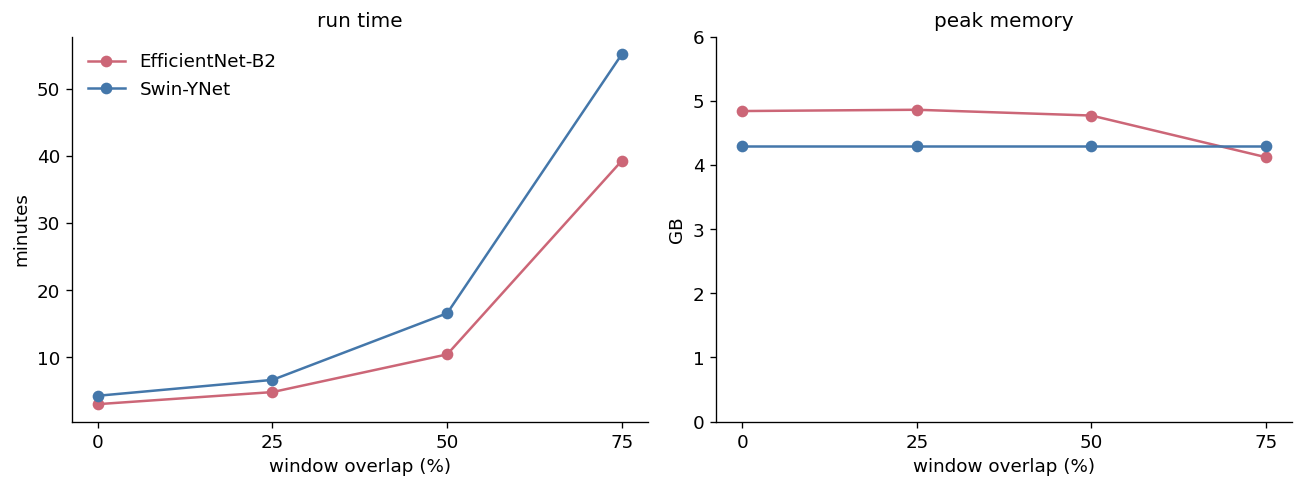

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for mdl in MODELS:
    s = res[res.model == mdl]
    axes[0].plot(s["overlap"], s["time_min"], "o-", color=MODEL_COLOR[mdl], label=MODEL_LABEL[mdl])
    axes[1].plot(s["overlap"], s["peak_GB"], "o-", color=MODEL_COLOR[mdl], label=MODEL_LABEL[mdl])
axes[0].set_title("run time"); axes[0].set_ylabel("minutes")
axes[1].set_title("peak memory"); axes[1].set_ylabel("GB"); axes[1].set_ylim(0, 6)
for ax in axes:
    ax.set_xlabel("window overlap (%)"); ax.set_xticks(OVERLAPS)
axes[0].legend()
plt.tight_layout(); plt.show()

**Interpretation.** EfficientNet runs faster than Swin-YNet at every overlap. For
both models run time climbs steeply toward 75% as the window count explodes, while
peak memory stays roughly flat (about 4.3 GB for Swin-YNet, 4.8 GB for
EfficientNet), since memory is set by rebuilding the two full images, not by the
overlap.

## 6. Voting strictness

A follow-up to the overlap result. With overlap, each pixel is judged by several
windows; so far a pixel is burned if more than half agree. Here we make the vote
stricter, requiring at least 50, 60, or 70 percent of the covering windows to
agree. It matters because a stricter vote should trade false alarms for misses.
The reader will see how that trade moves.

### 6.1 Effect of a stricter vote

We use the 75% overlap run, where each pixel is covered by up to 16 windows, so
the vote fraction is finely graded and the 50, 60 and 70 percent thresholds are
clearly distinct.

#### 6.1.1 Scores by voting threshold

**Objective.** Measure precision, recall, F1 and MCC as the vote gets stricter.
**Assumption.** A pixel is burned if at least the threshold percent of its
covering windows voted burned; at 75% overlap each pixel has up to 16 windows, so
50, 60 and 70 percent are distinct.

In [16]:
VOTE_OV = 75                 # densest coverage, so thresholds are distinct
THRESHOLDS = [50, 60, 70]
votes_maps = discover("votes")

rows = []
for mdl in MODELS:
    v = read(votes_maps[(mdl, VOTE_OV)])           # percent of windows voting burned
    for thr in THRESHOLDS:
        p = (v != 255) & (v >= thr) & comp
        TP = int((p & t).sum()); FP = int((p & ~t).sum())
        FN = int((~p & t).sum()); TN = int((~p & ~t & comp).sum())
        rows.append({"model": mdl, "vote_pct": thr, "burned_ha": (TP+FP)*PIX_HA,
                     "precision": TP/(TP+FP), "recall": TP/(TP+FN),
                     "F1": 2*TP/(2*TP+FP+FN), "MCC": mcc(TP, FP, FN, TN)})
vote_stats = pd.DataFrame(rows)
vote_stats.round(3)

,model,vote_pct,burned_ha,precision,recall,F1,MCC
0,efficientnet_b2,50,16851.79,0.588,0.931,0.721,0.734
1,efficientnet_b2,60,15374.63,0.637,0.920,0.753,0.760
2,efficientnet_b2,70,14144.59,0.683,0.908,0.779,0.782
3,swin_ynet,50,23928.54,0.397,0.893,0.550,0.585
4,swin_ynet,60,19134.07,0.484,0.870,0.622,0.640
5,swin_ynet,70,15594.18,0.575,0.842,0.683,0.689


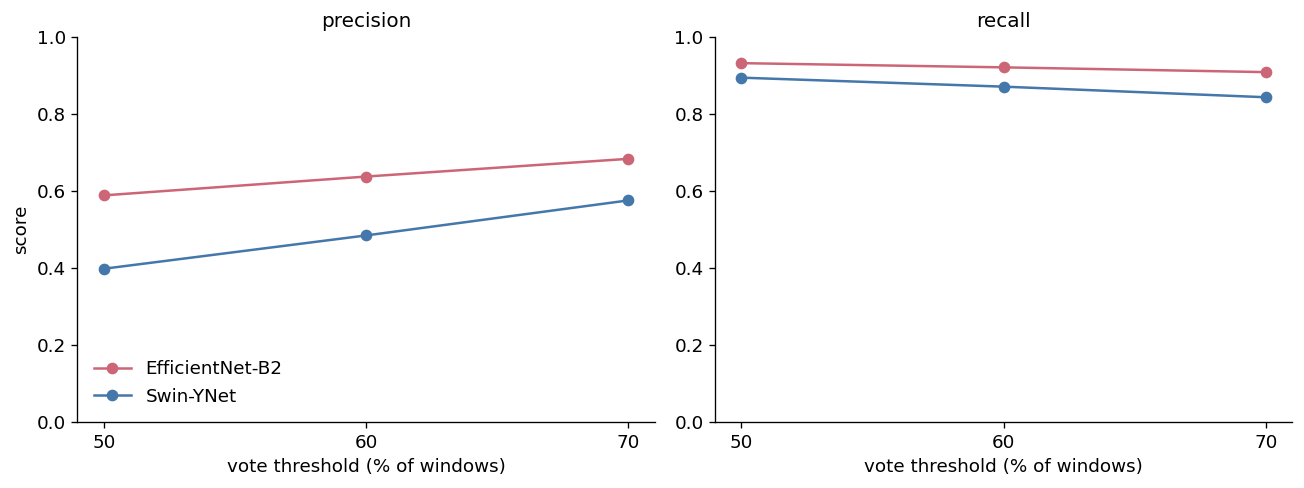

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
for ax, metric in zip(axes, ["precision", "recall"]):
    for mdl in MODELS:
        s = vote_stats[vote_stats.model == mdl]
        ax.plot(s["vote_pct"], s[metric], "o-", color=MODEL_COLOR[mdl], label=MODEL_LABEL[mdl])
    ax.set_title(metric); ax.set_xlabel("vote threshold (% of windows)")
    ax.set_ylim(0, 1); ax.set_xticks(THRESHOLDS)
axes[0].set_ylabel("score"); axes[0].legend(loc="lower left")
plt.tight_layout(); plt.show()

**Interpretation.** A stricter vote raises precision and lowers recall for both
models, the expected trade, and here it is a good trade: F1 and MCC keep rising
through 70 percent while recall barely drops. The best setting across all the
experiments is EfficientNet at 75% overlap with a 70 percent vote (F1 and MCC
about 0.78). EfficientNet stays ahead of Swin-YNet at every strictness.

## 7. Threshold curves: ROC and precision-recall

The raw models give a hard yes or no, but the overlap vote fraction (the percent
of windows that voted burned) is a real score we can sweep. This section draws
ROC and precision-recall curves from it for every model-and-overlap case. It
matters because it shows the full trade-off, not a single operating point. The
reader will also see why, under heavy class imbalance, ROC looks rosy and
precision-recall is the more honest view.

### 7.1 Sweeping the vote threshold

For each case we count true and false positives at every integer vote threshold
(0 to 100), then build both curves from those counts.

#### 7.1.1 ROC curves

**Objective.** Show the true-positive rate against the false-positive rate as the
vote threshold sweeps, with the area under the curve (AUC) per case.
**Assumption.** The score is the vote fraction; only observed pixels inside
Portugal are scored.

In [18]:
def curve_counts(votes):
    """At each integer vote threshold 0..100, count TP and FP (separable, so fast)."""
    m = (votes != 255) & scored
    s = votes[m]; y = truth[m]
    P = int(y.sum()); N = int((~y).sum())
    hp = np.bincount(s[y],  minlength=101).astype(float)
    hn = np.bincount(s[~y], minlength=101).astype(float)
    tp = np.cumsum(hp[::-1])[::-1]      # TP at threshold k = positives scoring >= k
    fp = np.cumsum(hn[::-1])[::-1]
    return tp, fp, P, N

VOTE_CASES = sorted(discover("votes"))             # (model, overlap) pairs with votes
ovs = sorted({ov for (_, ov) in VOTE_CASES})
counts = {case: curve_counts(read(discover("votes")[case])) for case in VOTE_CASES}

roc_curves, roc_auc = {}, {}
for case in VOTE_CASES:
    tp, fp, P, N = counts[case]
    tpr = np.concatenate([[0.0], tp / P]); fpr = np.concatenate([[0.0], fp / N])
    o = np.argsort(fpr); fpr, tpr = fpr[o], tpr[o]
    roc_curves[case] = (fpr, tpr); roc_auc[case] = float(np.trapezoid(tpr, fpr))

pd.DataFrame([{"model": m, "overlap": ov, "ROC_AUC": round(roc_auc[(m, ov)], 3)}
              for (m, ov) in VOTE_CASES])

,model,overlap,ROC_AUC
0,efficientnet_b2,50,0.971
1,efficientnet_b2,75,0.978
2,swin_ynet,50,0.955
3,swin_ynet,75,0.967


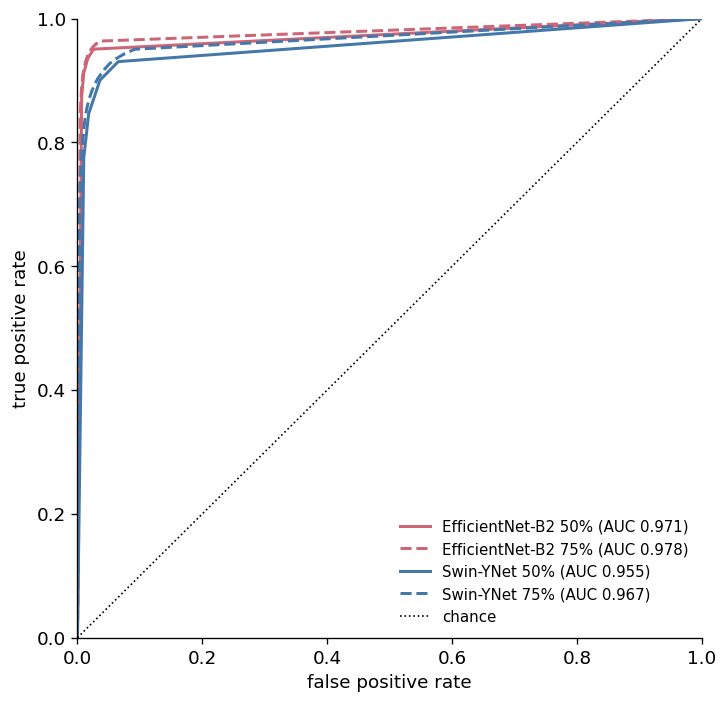

In [19]:
fig, ax = plt.subplots(figsize=(6.2, 6))
for (mdl, ov) in VOTE_CASES:
    fpr, tpr = roc_curves[(mdl, ov)]
    ls = "-" if ov == min(ovs) else "--"
    ax.plot(fpr, tpr, color=MODEL_COLOR[mdl], linestyle=ls, lw=1.8,
            label=f"{MODEL_LABEL[mdl]} {ov}% (AUC {roc_auc[(mdl, ov)]:.3f})")
ax.plot([0, 1], [0, 1], "k:", lw=1, label="chance")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation.** All four curves hug the top-left corner with AUC near 0.96
to 0.98, EfficientNet above Swin-YNet and 75% overlap slightly above 50%. But
these numbers are optimistic: burned pixels are a tiny fraction of the tile, so
the false-positive rate stays low even with many false alarms, because its
denominator is the huge True Negative count. ROC flatters an imbalanced detector.

#### 7.1.2 Precision-recall curves

**Objective.** Show precision against recall as the vote threshold sweeps, with
the area under the curve (AP) per case. **Assumption.** Same scores and pixels as
the ROC; precision-recall ignores True Negatives.

In [20]:
pr_curves, pr_auc = {}, {}
for case in VOTE_CASES:
    tp, fp, P, N = counts[case]
    recall = tp / P
    precision = np.where(tp + fp > 0, tp / np.maximum(tp + fp, 1), 1.0)
    o = np.argsort(recall)
    # extend to recall 0 (the strictest threshold's precision) so the curve and
    # the average precision cover the full recall range
    rec_s = np.concatenate([[0.0], recall[o]])
    prec_s = np.concatenate([[precision[o][0]], precision[o]])
    pr_curves[case] = (rec_s, prec_s)
    pr_auc[case] = float(np.sum(np.diff(rec_s) * prec_s[1:]))   # average precision (AP)

pd.DataFrame([{"model": m, "overlap": ov, "PR_AUC": round(pr_auc[(m, ov)], 3)}
              for (m, ov) in VOTE_CASES])

,model,overlap,PR_AUC
0,efficientnet_b2,50,0.677
1,efficientnet_b2,75,0.748
2,swin_ynet,50,0.532
3,swin_ynet,75,0.693


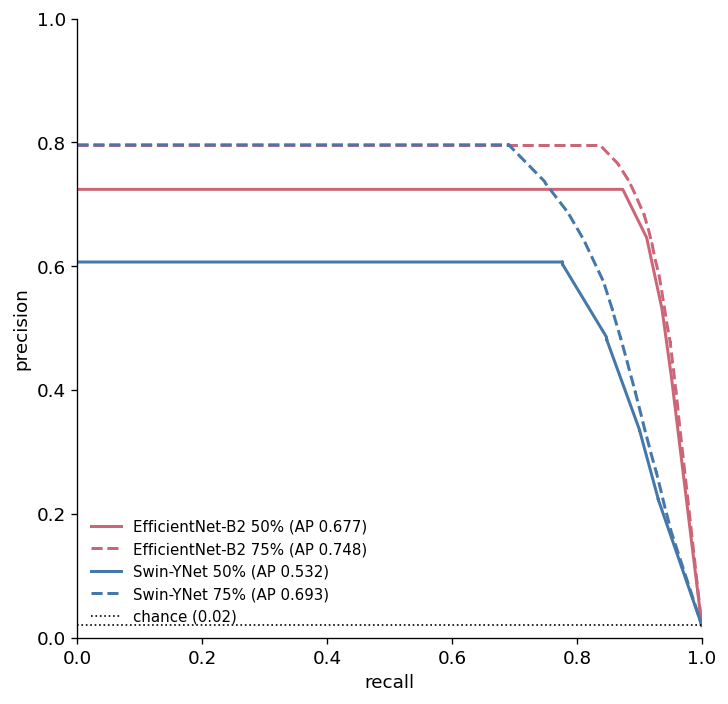

In [21]:
prevalence = (truth & scored).sum() / scored.sum()
fig, ax = plt.subplots(figsize=(6.2, 6))
for (mdl, ov) in VOTE_CASES:
    rec_s, prec_s = pr_curves[(mdl, ov)]
    ls = "-" if ov == min(ovs) else "--"
    ax.plot(rec_s, prec_s, color=MODEL_COLOR[mdl], linestyle=ls, lw=1.8,
            label=f"{MODEL_LABEL[mdl]} {ov}% (AP {pr_auc[(mdl, ov)]:.3f})")
ax.axhline(prevalence, color="k", ls=":", lw=1, label=f"chance ({prevalence:.2f})")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()

**Interpretation.** The precision-recall curves are far more sober than the ROC,
because they ignore True Negatives. They show the real cost of the false alarms:
to reach high recall, precision drops. EfficientNet still dominates Swin-YNet, and
its curve stays much higher, matching the precision and F1 numbers from the
earlier sections. For this imbalanced problem the precision-recall view (and MCC)
is the trustworthy summary; ROC is a familiar but flattering supplement.

## 8. Summary

EfficientNet-B2 outperforms Swin-YNet at every overlap level, with higher
precision, recall, F1 and MCC, and it runs faster. For both models, overlap with
a majority vote filters false alarms and the accuracy peaks at 50% overlap, with
75% giving back some of the gain at a large time cost. The best setting tested is
EfficientNet-B2 at 50% overlap (F1 about 0.76, MCC about 0.76). This rests on the
EfficientNet band order, which should be confirmed with the model author before
the result is final.